In [3]:
import sys
import os

sys.path.append(os.path.abspath('..'))


from helpers.mysql_connections import create_mysql_engine

import pandas as pd
import matplotlib.pyplot as plt

engine = create_mysql_engine()

query = 'SELECT * FROM results'
df_results = pd.read_sql( query, engine )
df_results.head(5)




,id,campaign_id,user_id,r_id,email,first_name,last_name,status,ip,latitude,longitude,position,send_date,reported,modified_date
0,1,101,1,AzK6Fg,andresrosales1@corpnet.com,Andres,Rosales,Clicked Link,172.219.4.215,13.678529,-89.248728,Estudiante,2026-03-15 14:07:00,0,2026-03-15 14:15:43
1,2,101,1,MKrJE7,roberto.escobar2@servicios.local,Roberto,Escobar,Email Opened,171.72.253.37,13.765087,-89.130911,Estudiante,2026-03-15 23:33:00,0,2026-03-15 23:40:48
2,3,101,1,itc3EV,andrescortez3@techzone.io,Andres,Cortez,Email Opened,181.252.57.239,13.779004,-89.264338,Estudiante,2026-03-15 20:01:00,0,2026-03-15 20:09:37
3,4,101,1,3hKdJy,adrian.padilla4@campusmail.edu,Adrian,Padilla,Email Opened,187.212.105.99,13.644827,-89.148701,Estudiante,2026-03-15 20:13:00,0,2026-03-15 20:16:33
4,5,101,1,LK9bHL,oscarpadilla5@techzone.io,Oscar,Padilla,Clicked Link,182.6.70.98,13.817546,-89.154148,Estudiante,2026-03-15 21:59:00,0,2026-03-15 22:00:49


In [9]:

## Porcentage of emails with URL clicked

q_opened = 'SELECT * FROM results WHERE status = "Email Opened"'
q_emails_opened_not_reported = 'SELECT * FROM results WHERE status = "Email Opened" and reported = 0'
q_emails_opened_and_reported = 'SELECT * FROM results WHERE status = "Email Opened" and reported = 1'


q_opened_clicked = 'SELECT * FROM results WHERE status = "Clicked Link"'
q_emails_clicked_not_reported = 'SELECT * FROM results WHERE status = "Clicked Link" and reported = 0'
q_emails_clicked_and_reported = 'SELECT * FROM results WHERE status = "Clicked Link" and reported = 1'

q_submitted_data = 'SELECT * FROM results WHERE status = "Submitted Data"'
q_emails_submitted_not_reported = 'SELECT * FROM results WHERE status = "Submitted Data" and reported = 0'
q_emails_submitted_and_reported = 'SELECT * FROM results WHERE status = "Submitted Data" and reported = 1'

q_emails_not_reported = 'SELECT * FROM results WHERE reported = 0'
q_emails_reported = 'SELECT * FROM results WHERE reported = 1'
## Total of emails

total_emails = len(df_results)

## Number of emails with URLs that were clicked

df_emails_opened = pd.read_sql( q_opened, engine )
emails_opened = len( df_emails_opened )

df_emails_clicked = pd.read_sql( q_opened_clicked, engine )
emails_clicked = len( df_emails_clicked )

df_emails_submitted = pd.read_sql( q_submitted_data, engine )
emails_submitted = len( df_emails_submitted )


df_emails_clicked_not_reported = pd.read_sql( q_emails_clicked_not_reported, engine )
emails_clicked_not_reported = len( df_emails_clicked_not_reported )

df_emails_clicked_and_reported = pd.read_sql( q_emails_clicked_and_reported, engine )
emails_clicked_and_reported = len( df_emails_clicked_and_reported )

emails_clicked_not_reported_prtg = round( emails_clicked_not_reported / (emails_clicked_not_reported + emails_clicked_and_reported) * 100,2)
emails_clicked_and_reported_prtg = round( emails_clicked_and_reported / (emails_clicked_not_reported + emails_clicked_and_reported) * 100,2)

df_emails_opened_not_reported = pd.read_sql( q_emails_opened_not_reported, engine )
emails_opened_not_reported = len( df_emails_opened_not_reported )

df_emails_opened_and_reported = pd.read_sql( q_emails_opened_and_reported, engine )
emails_opened_and_reported = len( df_emails_opened_and_reported )

emails_opened_not_reported_prtg = round( emails_opened_not_reported / (emails_opened_and_reported + emails_opened_not_reported) * 100,2)
emails_opened_and_reported_prtg = round( emails_opened_and_reported / (emails_opened_and_reported + emails_opened_not_reported) * 100,2)

df_emails_submitted_not_reported = pd.read_sql( q_emails_submitted_not_reported, engine )
emails_submitted_not_reported = len( df_emails_submitted_not_reported )

df_emails_submitted_and_reported = pd.read_sql( q_emails_submitted_and_reported, engine )
emails_submitted_and_reported = len( df_emails_submitted_and_reported )

emails_submitted_not_reported_prtg = round( emails_submitted_not_reported / (emails_submitted_not_reported + emails_submitted_and_reported) * 100,2)
emails_submitted_and_reported_prtg = round( emails_submitted_and_reported / (emails_submitted_not_reported + emails_submitted_and_reported) * 100,2)

df_emails_not_reported = pd.read_sql( q_emails_not_reported, engine )
emails_not_reported = len( df_emails_not_reported )

df_emails_reported = pd.read_sql( q_emails_reported, engine )
emails_reported = len( df_emails_reported )

emails_not_reported_prtg = round( emails_reported / (emails_reported + emails_not_reported) * 100,2)
emails_reported_prtg = round( emails_not_reported / (emails_reported + emails_not_reported) * 100,2)


## Metrics Calculations

emails_opened_prtg = round( emails_opened / total_emails * 100,2)
emails_clicked_prtg = round( emails_clicked / total_emails * 100,2)
emails_submitted_prtg = round( emails_submitted / total_emails * 100,2)

overall_metrics_dict = {
    'Emails Opened %': [f'{emails_opened_prtg}%'],
    'Clicked Link %' : [f'{emails_clicked_prtg}%'],
    'Submitted Data %': [f'{emails_submitted_prtg}%']
}


df_overall_metrics = pd.DataFrame(overall_metrics_dict, index= ['Values'], columns = ['Emails Opened %', 'Clicked Link %', 'Submitted Data %']  )

---

# **Presentacion de la Informacion**

---

In [5]:
display( df_overall_metrics )

,Emails Opened %,Clicked Link %,Submitted Data %
Values,39.6%,35.4%,25.0%


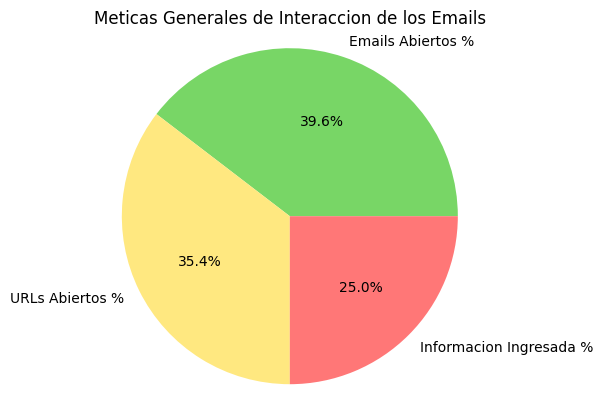

In [20]:
labels = ['Emails Abiertos %', 'URLs Abiertos %', 'Informacion Ingresada %']
values = [emails_opened_prtg, emails_clicked_prtg, emails_submitted_prtg]
colors = [ "#78D666","#FFE880", "#FF7777" ]

plt.pie( values, labels=labels, colors=colors,  autopct='%1.1f%%')

plt.title('Meticas Generales de Interaccion de los Emails')
plt.axis('equal')

plt.show()

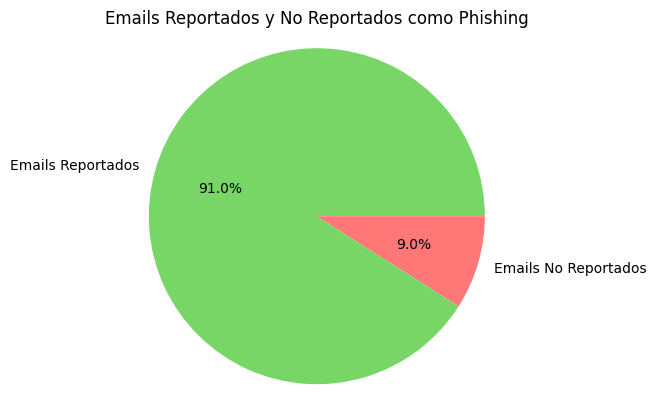

In [19]:
labels = ['Emails Reportados', 'Emails No Reportados']
values = [emails_reported_prtg, emails_not_reported_prtg]
colors = ["#78D666", "#FF7777"]

plt.pie( values, labels=labels, colors=colors,  autopct='%1.1f%%')

plt.title('Emails Reportados y No Reportados como Phishing')
plt.axis('equal')

plt.show()